# Hospital Provider Cost Reports — EDA & Feature Engineering (2014–2023)



In [1]:
from google.colab import userdata
import os

token    = userdata.get('GitHub')
owner    = "austinmallie"
repo     = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Repo already cloned. Pulling latest changes...
/content/ADS599_Capstone
Already up to date.
/content/ADS599_Capstone


## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings, re, os
warnings.filterwarnings('ignore')



In [3]:
FILE_MAP = {
    2014: 'Hospital_Provider_Cost_Report_2014.csv',
    2015: 'Hospital_Provider_Cost_Report_2015.csv',
    2016: 'Hospital_Provider_Cost_Report_2016.csv',
    2017: 'Hospital_Provider_Cost_Report_2017.csv',
    2018: 'Hospital_Provider_Cost_Report_2018.csv',
    2019: 'Hospital_Provider_Cost_Report_2019.csv',
    2020: 'Hospital_Provider_Cost_Report_2020.csv',
    2021: 'Hospital_Provider_Cost_Report_2021.csv',
    2022: 'Hospital_Provider_Cost_Report_2022.csv',
    2023: 'CostReport_2023_Final.csv',
}

frames = []
for year, fname in FILE_MAP.items():
    path = os.path.join("Data-Folder/Cost-Report-Data", fname)
    tmp  = pd.read_csv(path, low_memory=False)
    tmp['report_year'] = year
    frames.append(tmp)
    print(f"  {year}: {len(tmp):,} rows  |  {tmp.shape[1]} cols")

print(f"\n Total files loaded: {len(frames)}")



  2014: 6,250 rows  |  118 cols
  2015: 6,257 rows  |  118 cols
  2016: 6,211 rows  |  118 cols
  2017: 6,174 rows  |  118 cols
  2018: 6,160 rows  |  118 cols
  2019: 6,121 rows  |  118 cols
  2020: 6,059 rows  |  118 cols
  2021: 6,053 rows  |  118 cols
  2022: 6,064 rows  |  118 cols
  2023: 6,103 rows  |  118 cols

 Total files loaded: 10


## 3. Standardise Dates & Rename Columns

In [4]:

all_cols   = [set(f.columns) for f in frames]
base_cols  = set.intersection(*all_cols)
extra_cols = set.union(*all_cols) - base_cols

print(f"Columns present in ALL years  : {len(base_cols)}")
print(f"Columns present in SOME years : {len(extra_cols)}")
if extra_cols:
    print("  Extra columns:", extra_cols)

Columns present in ALL years  : 118
Columns present in SOME years : 0


In [5]:
# Standardize Column Names: strip whitespace, lowercase, replace special chars
def clean_col(c):
    c = c.strip()
    c = re.sub(r'[^A-Za-z0-9]+', '_', c)
    return c.lower().strip('_')

for i, f in enumerate(frames):
    frames[i].columns = [clean_col(c) for c in f.columns]

#  Stack all years
df = pd.concat(frames, ignore_index=True, sort=False)

print(f"Combined shape : {df.shape}")
print(f"Years present  : {sorted(df['report_year'].unique())}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Combined shape : (61452, 118)
Years present  : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Memory usage   : 88.8 MB


## 4. Drop Columns with >50% Missingness

In [6]:
missing_pct = df.isnull().mean()
sparse_cols = missing_pct[missing_pct > 0.50].sort_values(ascending=False)

print(f'Columns dropped ({len(sparse_cols)}) — missingness >50%:')
for col, pct in sparse_cols.items():
    print(f'  {pct:6.1%}  {col}')

df = df.drop(columns=sparse_cols.index)
print(f'\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Columns dropped (31) — missingness >50%:
  100.0%  drg_amounts_other_than_outlier_payments
   97.5%  hospital_total_days_title_v_for_adults_peds
   97.4%  hospital_total_discharges_title_v_for_adults_peds
   97.4%  total_discharges_title_v
   97.3%  total_days_title_v
   95.4%  notes_receivable
   95.2%  unsecured_loans
   93.6%  wage_related_costs_rhc_fqhc
   93.3%  wage_related_costs_for_part_a_teaching_physicians
   91.1%  health_information_technology_designated_assets
   87.1%  wage_related_costs_for_interns_and_residents
   86.8%  mortgage_payable
   84.4%  deferred_income
   83.8%  net_revenue_from_stand_alone_chip
   83.6%  minor_equipment_depreciable
   83.6%  stand_alone_chip_charges
   80.5%  total_ime_payment
   80.3%  temporary_investments
   77.4%  number_of_interns_and_residents_fte
   74.9%  outlier_payments_for_discharges
   74.7%  managed_care_simulated_payments
   69.3%  total_other_expenses
   63.2%  payroll_taxes_payable
   60.6%  investments
   58.9%  notes_payabl

## 5. Feature Engineering

In [7]:
fe = df.copy()

RENAME = {
    'provider_ccn'                         : 'ccn',
    'state_code'                           : 'state',
    'rural_versus_urban'                   : 'rural_urban',
    'type_of_control'                      : 'control_type',
    'number_of_beds'                       : 'beds',
    'less_total_operating_expense'         : 'total_operating_expense',
    'total_salaries_from_worksheet_a'      : 'total_salaries',
    'total_discharges_v_xviii_xix_unknown' : 'total_discharges',
    'total_days_v_xviii_xix_unknown'       : 'total_days',
    'cost_of_charity_care'                 : 'charity_care_cost',
    'total_bad_debt_expense'               : 'bad_debt_expense',
    'fte_employees_on_payroll'             : 'fte_employees',
    'contract_labor_direct_patient_care'   : 'contract_labor',
    'net_revenue_from_medicaid'            : 'medicaid_net_revenue',
    'overhead_non_salary_costs'            : 'overhead_costs',
    'medicare_cbsa_number'                 : 'cbsa',
}
fe.rename(columns={k: v for k, v in RENAME.items() if k in fe.columns}, inplace=True)

def safe_div(a, b, fill=np.nan):
    """Division with zero/null guard."""
    return np.where((b.notna()) & (b != 0), a / b, fill)

# ── Profitability ─────────────────────────────────────────────────────────────
fe['net_profit_margin']        = safe_div(fe['net_income'],          fe['net_patient_revenue'])
fe['operating_margin']         = safe_div(fe['net_income'],          fe['total_operating_expense'])
fe['cost_to_revenue_ratio']    = safe_div(fe['total_costs'],         fe['total_patient_revenue'])
fe['revenue_minus_cost']       = fe['total_patient_revenue'] - fe['total_costs']

# ── Revenue mix ───────────────────────────────────────────────────────────────
fe['outpatient_revenue_share'] = safe_div(fe['outpatient_revenue'],  fe['total_patient_revenue'])
fe['inpatient_revenue_share']  = safe_div(fe['inpatient_revenue'],   fe['total_patient_revenue'])

# ── Cost structure ────────────────────────────────────────────────────────────
fe['salary_cost_share']        = safe_div(fe['total_salaries'],      fe['total_costs'])
fe['overhead_cost_share']      = safe_div(fe['overhead_costs'],      fe['total_costs'])
fe['depreciation_cost_share']  = safe_div(fe['depreciation_cost'],   fe['total_costs'])
fe['contract_labor_share']     = safe_div(fe['contract_labor'],      fe['total_salaries'])

# ── Uncompensated care ────────────────────────────────────────────────────────
fe['charity_care_pct_revenue'] = safe_div(fe['charity_care_cost'],   fe['net_patient_revenue'])
fe['bad_debt_pct_revenue']     = safe_div(fe['bad_debt_expense'],    fe['net_patient_revenue'])

# ── Per-unit efficiency ───────────────────────────────────────────────────────
fe['revenue_per_bed']          = safe_div(fe['net_patient_revenue'], fe['beds'])
fe['cost_per_bed']             = safe_div(fe['total_costs'],         fe['beds'])
fe['net_income_per_bed']       = safe_div(fe['net_income'],          fe['beds'])
fe['revenue_per_discharge']    = safe_div(fe['net_patient_revenue'], fe['total_discharges'])
fe['cost_per_discharge']       = safe_div(fe['total_costs'],         fe['total_discharges'])
fe['net_income_per_discharge'] = safe_div(fe['net_income'],          fe['total_discharges'])
fe['revenue_per_day']          = safe_div(fe['net_patient_revenue'], fe['total_days'])
fe['cost_per_day']             = safe_div(fe['total_costs'],         fe['total_days'])
fe['revenue_per_fte']          = safe_div(fe['net_patient_revenue'], fe['fte_employees'])
fe['cost_per_fte']             = safe_div(fe['total_costs'],         fe['fte_employees'])
fe['salary_per_fte']           = safe_div(fe['total_salaries'],      fe['fte_employees'])
fe['occupancy_rate']           = safe_div(fe['total_days'],          fe['beds'] * 365)
fe['discharge_per_bed']        = safe_div(fe['total_discharges'],    fe['beds'])

# ── Balance sheet / solvency ──────────────────────────────────────────────────
fe['debt_to_equity']           = safe_div(fe['total_liabilities'],   fe['total_fund_balances'])
fe['asset_turnover']           = safe_div(fe['net_patient_revenue'], fe['total_assets'])
fe['equity_ratio']             = safe_div(fe['total_fund_balances'], fe['total_assets'])
fe['liability_ratio']          = safe_div(fe['total_liabilities'],   fe['total_assets'])
if 'total_current_assets' in fe.columns and 'total_current_liabilities' in fe.columns:
    fe['current_ratio']        = safe_div(fe['total_current_assets'], fe['total_current_liabilities'])
    fe['net_working_capital']  = fe['total_current_assets'] - fe['total_current_liabilities']

# ── Payer mix ─────────────────────────────────────────────────────────────────
fe['medicaid_revenue_share']   = safe_div(fe['medicaid_net_revenue'],         fe['net_patient_revenue'])
fe['medicare_discharge_share'] = safe_div(fe['total_discharges_title_xviii'], fe['total_discharges'])

# ── Year-over-year changes ────────────────────────────────────────────────────
fe.sort_values(['ccn', 'report_year'], inplace=True)
for col in ['net_patient_revenue', 'total_costs', 'net_income', 'beds', 'fte_employees']:
    if col not in fe.columns: continue
    shifted = fe.groupby('ccn')[col].shift(1)
    fe[f'{col}_yoy_change']     = fe[col] - shifted
    fe[f'{col}_yoy_pct_change'] = safe_div(fe[col] - shifted, shifted.abs()) * 100

# ── 2-year rolling median ─────────────────────────────────────────────────────
for col in ['net_patient_revenue', 'total_costs']:
    fe[f'{col}_2yr_rolling_median'] = (
        fe.groupby('ccn')[col].transform(lambda x: x.rolling(2, min_periods=1).median()))

# ── Temporal era flags ────────────────────────────────────────────────────────
fe['years_in_dataset'] = fe.groupby('ccn')['report_year'].transform(lambda x: x - x.min())
fe['pre_covid']        = (fe['report_year'] <= 2019).astype(int)
fe['covid_year']       = (fe['report_year'] == 2020).astype(int)
fe['post_covid']       = (fe['report_year'] >= 2021).astype(int)

# ── Log transforms (heavy-tailed financials) ──────────────────────────────────
for col in ['total_costs', 'net_patient_revenue', 'total_assets',
            'total_liabilities', 'fte_employees', 'total_salaries']:
    if col in fe.columns:
        fe[f'log_{col}'] = np.log1p(fe[col].clip(lower=0))

# ── Binary flags & size tiers ─────────────────────────────────────────────────
fe['is_profitable'] = (fe['net_income'].fillna(0) > 0).astype(int)
fe['high_charity']  = (fe['charity_care_pct_revenue'].fillna(0) > 0.05).astype(int)
fe['bed_tier']      = pd.qcut(fe['beds'].clip(lower=0), q=5,
                              labels=['Micro','Small','Medium','Large','Major'], duplicates='drop')
fe['revenue_tier']  = pd.qcut(fe['net_patient_revenue'].clip(lower=0), q=4,
                              labels=['Q1_Low','Q2_Mid-Low','Q3_Mid-High','Q4_High'], duplicates='drop')

orig_cols = set(df.columns)
new_feats = [c for c in fe.columns if c not in orig_cols]
print(f' Feature engineering complete.')
print(f'   Engineered features added : {len(new_feats)}')
print(f'   Shape: {fe.shape[0]:,} rows × {fe.shape[1]} columns')

 Feature engineering complete.
   Engineered features added : 75
   Shape: 61,452 rows × 146 columns


## 6. Drop Raw Input & Redundant Columns

Removes columns that were used purely as inputs to create engineered features,
accounting identities, charge columns, and low-value balance sheet detail.

###. Drop Erroneous `beds` Rows

In [9]:
DROP_COLS = [
    # Accounting identities
    'net_income_from_service_to_patients',   # ≈ net_income
    'total_income',                          # ≈ net_patient_revenue
    'total_liabilities_and_fund_balances',   # = total_assets

    #  Payer-split breakdowns → captured by medicare/medicaid_share
    'total_days_title_xviii', 'total_days_title_xix',
    'total_discharges_title_xviii', 'total_discharges_title_xix',
    'hospital_total_days_title_xviii_for_adults_peds',
    'hospital_total_days_title_xix_for_adults_peds',
    'hospital_total_days_v_xviii_xix_unknown_for_adults_peds',
    'hospital_total_discharges_title_xviii_for_adults_peds',
    'hospital_total_discharges_title_xix_for_adults_peds',
    'hospital_total_discharges_v_xviii_xix_unknown_for_adults_peds',

    #  Bed sub-totals → absorbed into beds / occupancy_rate / bed_tier
    'total_bed_days_available', 'number_of_beds_total_for_all_subproviders',
    'hospital_number_of_beds_for_adults_peds', 'hospital_total_bed_days_available_for_adults_peds',

    #  Salary sub-components → absorbed into total_salaries / salary_share
    'total_salaries_adjusted', 'wage_related_costs_core',

    #  Balance sheet line items → absorbed into current/fixed asset totals
    'land_improvements', 'prepaid_expenses', 'inventory',
    'land', 'buildings', 'fixed_equipment', 'major_movable_equipment',
    'general_fund_balance', 'total_other_assets', 'other_assets',

    #  Charge columns (charges ≠ revenue; skewed, low signal)
    'inpatient_total_charges', 'outpatient_total_charges',
    'combined_outpatient_inpatient_total_charges', 'medicaid_charges',

    # Other low-value detail
    'drg_amounts_after_october_1',
    'less_contractual_allowance_and_discounts_on_patients_accounts',
    'total_other_income',
    'other_long_term_liabilities', 'other_current_liabilities',
    'accounts_payable', 'salaries_wages_and_fees_payable',
    'total_fixed_assets',

    # Identifiers & free text
    'rpt_rec_num',
    'hospital_name',
    'street_address',
    'city',
    'zip_code',
    'county',
    'fiscal_year_begin_date',
    'fiscal_year_end_date',

    #  Covered by Hospital General join
    'state',
    'control_type',
    'rural_urban',
    'ccn_facility_type',
    'provider_type',
]

cols_found = [c for c in DROP_COLS if c in fe.columns]
fe_clean   = fe.drop(columns=cols_found, errors='ignore').copy()
print(f'Dropped {len(cols_found)} columns.')
print(f'Shape: {fe_clean.shape[0]:,} rows × {fe_clean.shape[1]} columns')

Dropped 54 columns.
Shape: 61,452 rows × 92 columns


In [11]:
BEDS_ERROR_THRESHOLD = 10_000
error_mask = fe_clean['beds'] > BEDS_ERROR_THRESHOLD
print(f'Rows dropped (beds > {BEDS_ERROR_THRESHOLD:,}): {error_mask.sum()}')
print(fe_clean[error_mask][['ccn','beds','report_year']]
      .sort_values('beds', ascending=False).to_string(index=False))
fe_clean = fe_clean[~error_mask].reset_index(drop=True)
print(f'\nFinal shape: {fe_clean.shape[0]:,} rows × {fe_clean.shape[1]} columns')

Rows dropped (beds > 10,000): 8
   ccn      beds  report_year
312018 6092016.0         2015
360044 1594784.0         2020
140158  144837.0         2020
131316   52913.0         2019
370215   28401.0         2019
223300   23363.0         2017
310028   17792.0         2016
 50179   13660.0         2016

Final shape: 61,444 rows × 92 columns


## 8. Exploratory Analysis

Visual Checks on the data before final merge

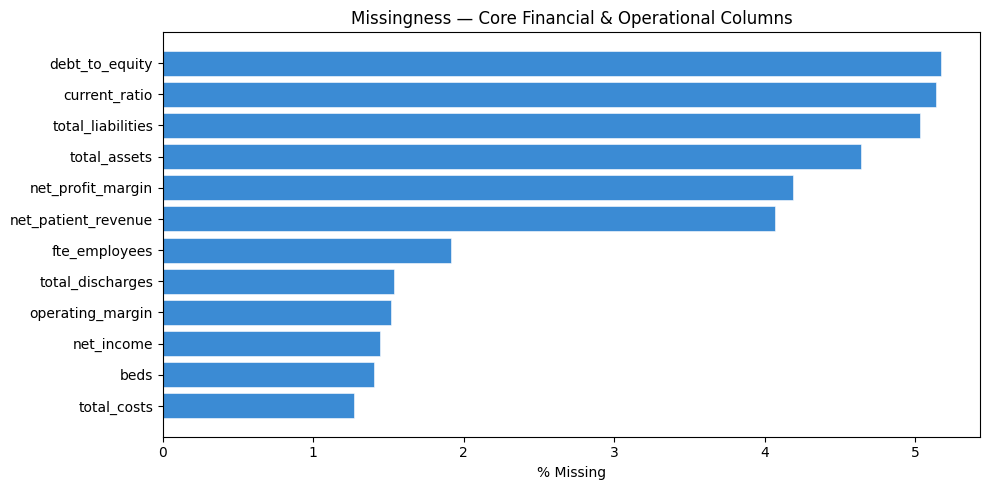

In [12]:
# Missingness heatmap on core columns
core_cols = ['total_costs','net_patient_revenue','net_income','total_assets',
             'total_liabilities','fte_employees','beds','total_discharges',
             'net_profit_margin','operating_margin','debt_to_equity','current_ratio']
core_cols = [c for c in core_cols if c in fe_clean.columns]

miss = fe_clean[core_cols].isnull().mean().sort_values(ascending=True) * 100
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(miss.index, miss.values, color='#3B8BD4', edgecolor='white', linewidth=0.4)
ax.set_xlabel('% Missing')
ax.set_title('Missingness — Core Financial & Operational Columns')
plt.tight_layout()
plt.show()

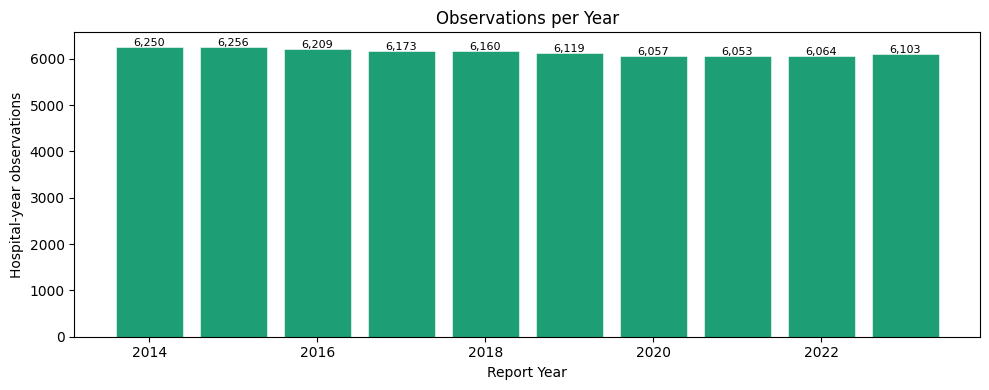

In [13]:
#  Row counts by year
year_counts = fe_clean['report_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(year_counts.index, year_counts.values, color='#1D9E75', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Report Year')
ax.set_ylabel('Hospital-year observations')
ax.set_title('Observations per Year')
for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y + 20, f'{y:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

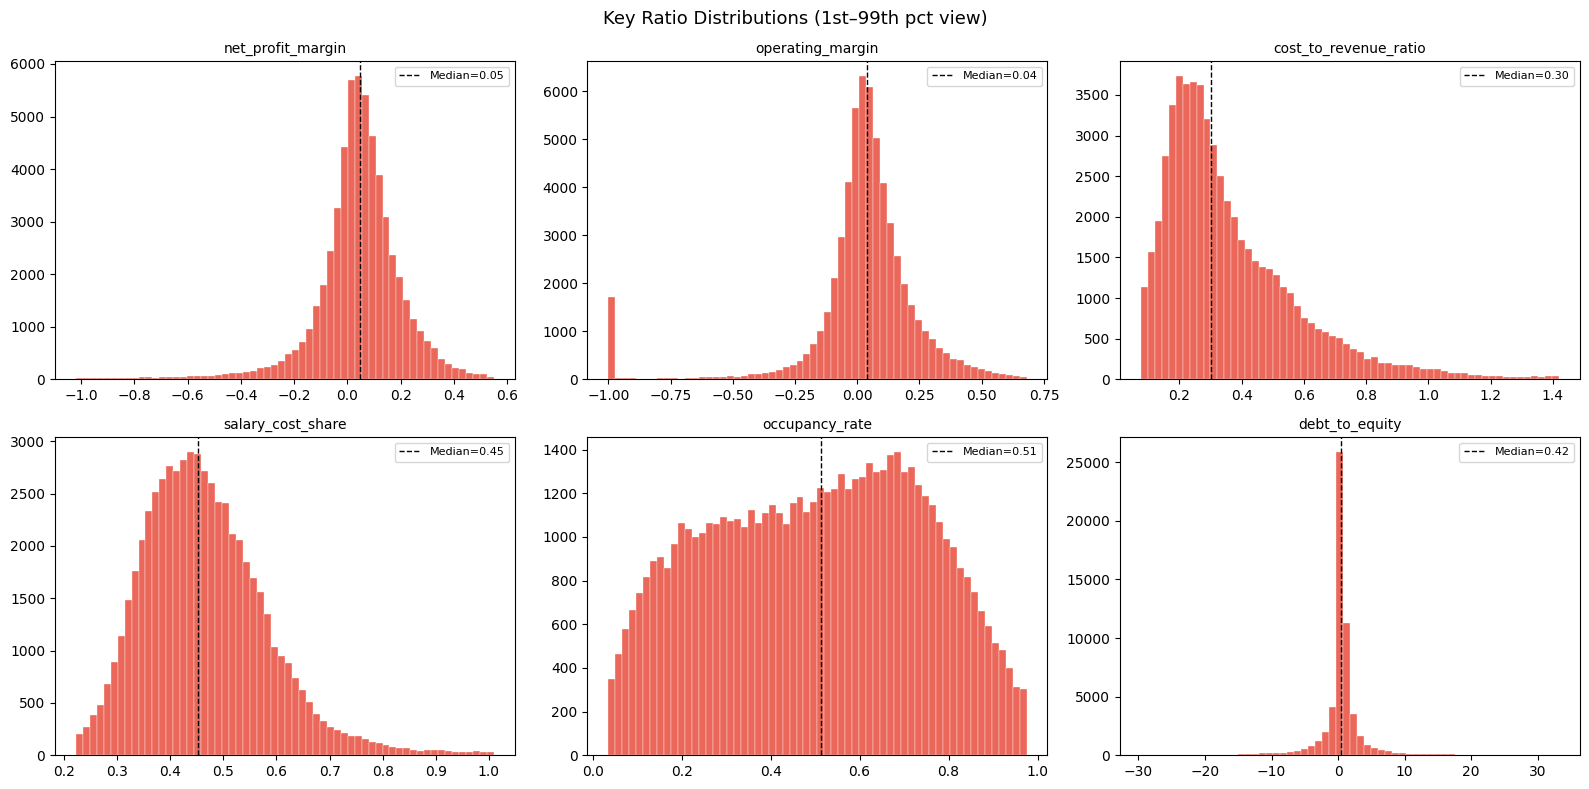

In [14]:
#  Distribution of key financial variables
plot_cols = ['net_profit_margin','operating_margin','cost_to_revenue_ratio',
             'salary_cost_share','occupancy_rate','debt_to_equity']
plot_cols = [c for c in plot_cols if c in fe_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols[:6]):
    vals = fe_clean[col].dropna()
    vals = vals[vals.between(vals.quantile(0.01), vals.quantile(0.99))]
    axes[i].hist(vals, bins=60, color='#E74C3C', edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[i].axvline(vals.median(), color='black', linestyle='--', linewidth=1,
                    label=f'Median={vals.median():.2f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle('Key Ratio Distributions (1st–99th pct view)', fontsize=13)
plt.tight_layout()
plt.show()

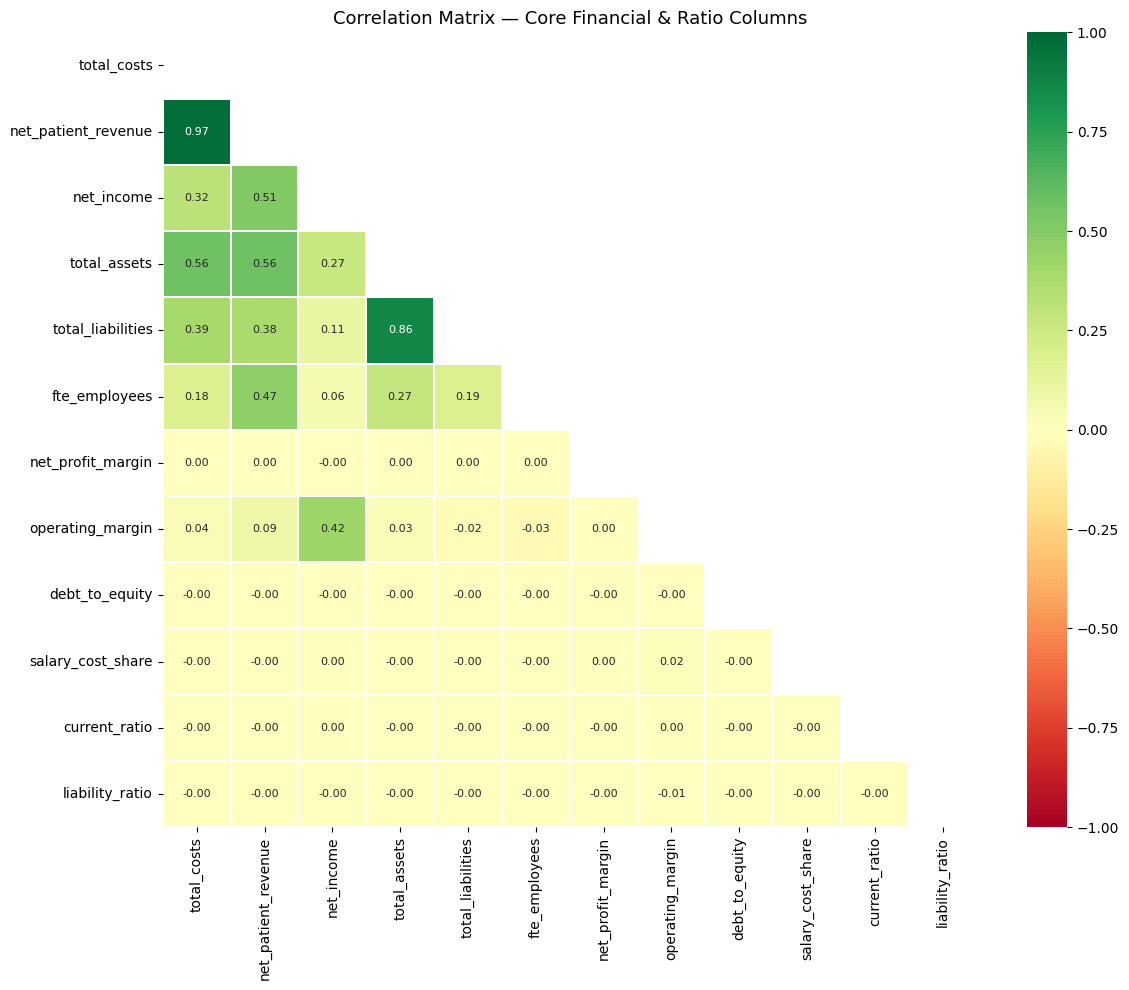

In [15]:
#  Correlation matrix — core financial columns
corr_cols = [c for c in ['total_costs','net_patient_revenue','net_income',
                          'total_assets','total_liabilities','fte_employees',
                          'net_profit_margin','operating_margin','debt_to_equity',
                          'salary_cost_share','current_ratio','liability_ratio']
             if c in fe_clean.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr = fe_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Core Financial & Ratio Columns', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Export `Cost_Report_Final.csv`

In [16]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [20]:
OUTPUT_PATH = '/content/drive/My Drive/Cost_Report_EDA_Final.csv'
fe_clean.to_csv(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / 1e6

print(f' Saved → {OUTPUT_PATH}  ({size_mb:.1f} MB)')
print(f'   Rows    : {fe_clean.shape[0]:,}')
print(f'   Columns : {fe_clean.shape[1]}')
print(f'\nColumn inventory:')
for c in fe_clean.columns:
    print(f'  {c}')

 Saved → /content/drive/My Drive/Cost_Report_EDA_Final.csv  (69.2 MB)
   Rows    : 61,444
   Columns : 92

Column inventory:
  ccn
  cbsa
  fte_employees
  total_days
  beds
  total_discharges
  charity_care_cost
  bad_debt_expense
  cost_of_uncompensated_care
  total_unreimbursed_and_uncompensated_care
  total_salaries
  overhead_costs
  depreciation_cost
  total_costs
  contract_labor
  cash_on_hand_and_in_banks
  accounts_receivable
  less_allowances_for_uncollectible_notes_and_accounts_receivable
  total_current_assets
  total_assets
  total_current_liabilities
  total_long_term_liabilities
  total_liabilities
  total_fund_balances
  inpatient_revenue
  outpatient_revenue
  total_patient_revenue
  net_patient_revenue
  total_operating_expense
  net_income
  cost_to_charge_ratio
  medicaid_net_revenue
  report_year
  net_profit_margin
  operating_margin
  cost_to_revenue_ratio
  revenue_minus_cost
  outpatient_revenue_share
  inpatient_revenue_share
  salary_cost_share
  overhead_co

## CSV for modeling

In [21]:
modeling_cols = [
    # Identifiers
    'ccn',
    'cbsa',
    'report_year',

    # Operational
    'beds',
    'fte_employees',
    'total_discharges',
    'total_days',

    # Income statement
    'inpatient_revenue',
    'outpatient_revenue',
    'total_patient_revenue',
    'net_patient_revenue',
    'total_operating_expense',
    'net_income',

    # Costs
    'total_costs',
    'total_salaries',
    'overhead_costs',
    'depreciation_cost',
    'contract_labor',
    'cost_to_charge_ratio',

    # Uncompensated care
    'charity_care_cost',
    'bad_debt_expense',
    'cost_of_uncompensated_care',
    'total_unreimbursed_and_uncompensated_care',

    # Balance sheet
    'cash_on_hand_and_in_banks',
    'accounts_receivable',
    'total_current_assets',
    'total_current_liabilities',
    'total_long_term_liabilities',
    'total_liabilities',
    'total_fund_balances',
    'total_assets',

    # Payer mix
    'medicaid_net_revenue'
]

# Filter the fe_clean DataFrame to include only the modeling columns
df_modeling = fe_clean[modeling_cols].copy()

# Define the output path for the new CSV file in Google Drive
MODELING_OUTPUT_PATH = '/content/drive/My Drive/Cost_Report_Final.csv'

# Save the filtered DataFrame to CSV
df_modeling.to_csv(MODELING_OUTPUT_PATH, index=False)

# Get file size for confirmation
size_mb_modeling = os.path.getsize(MODELING_OUTPUT_PATH) / 1e6

print(f' Saved modeling data to → {MODELING_OUTPUT_PATH}  ({size_mb_modeling:.1f} MB)')
print(f'   Rows    : {df_modeling.shape[0]:,}')
print(f'   Columns : {df_modeling.shape[1]}')

 Saved modeling data to → /content/drive/My Drive/Cost_Report_Final.csv  (17.5 MB)
   Rows    : 61,444
   Columns : 32
